# Predicting Price Moves with News Sentiment
## 📊 Task 1: Exploratory Data Analysis (EDA) on Financial News
#### **Goals:**
 - Understand headline characteristics
 - Identify key publishers
 - Analyze article publication trends
 - Visualize common topics in news headlines

### 1. Setup and Imports

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from collections import Counter

### 2. Load and Prepare Data

In [34]:
df = pd.read_csv("../data/raw_analyst_ratings.csv")

In [36]:
df.dropna(subset=['headline'], inplace=True)
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')
df.head()

C:\Users\Bereket\AppData\Local\Temp\ipykernel_15064\2980815604.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


## 3. Analyze Headline Length

In [37]:
df['headline_length'] = df['headline'].str.len()
df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

### Plot Headline Length Distribution

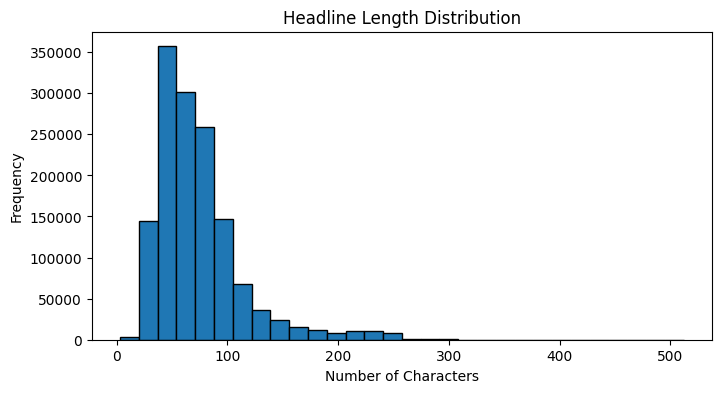

In [39]:
plt.figure(figsize=(8, 4))
df['headline_length'].hist(bins=30, edgecolor='black')
plt.title("Headline Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()

### 4. Top Publishers by Article Count

In [40]:
df['publisher'].value_counts().head(20)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

### Plot Top 10 Publishers

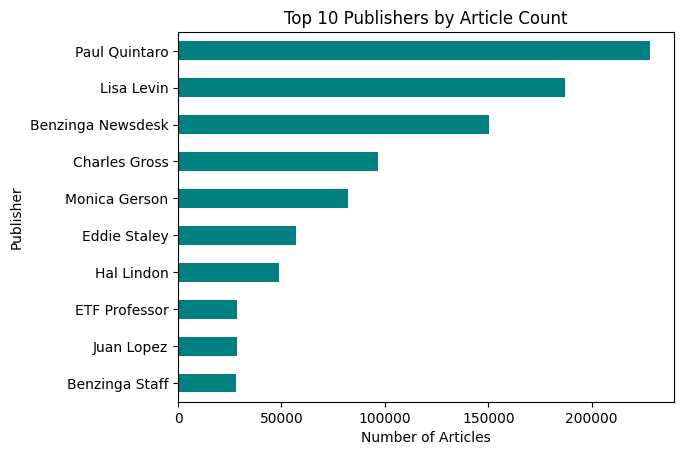

In [41]:
df['publisher'].value_counts().head(10).plot(kind='barh', color='teal')
plt.title("Top 10 Publishers by Article Count")
plt.xlabel("Number of Articles")
plt.ylabel("Publisher")
plt.gca().invert_yaxis()
plt.show()

### 5. Article Publication Trends Over Time

In [43]:
# Parse and normalize all datetime values to UTC
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

# Drop rows with invalid or missing dates
df.dropna(subset=['date'], inplace=True)


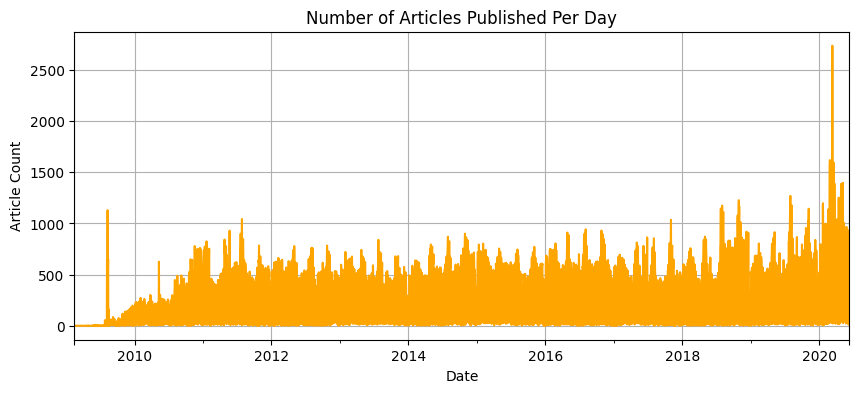

In [44]:
daily_counts = df.set_index('date').resample('D').size()

daily_counts.plot(figsize=(10, 4), color='orange')
plt.title("Number of Articles Published Per Day")
plt.xlabel("Date")
plt.ylabel("Article Count")
plt.grid(True)
plt.show()

### 6. Hour of Day When News Is Published

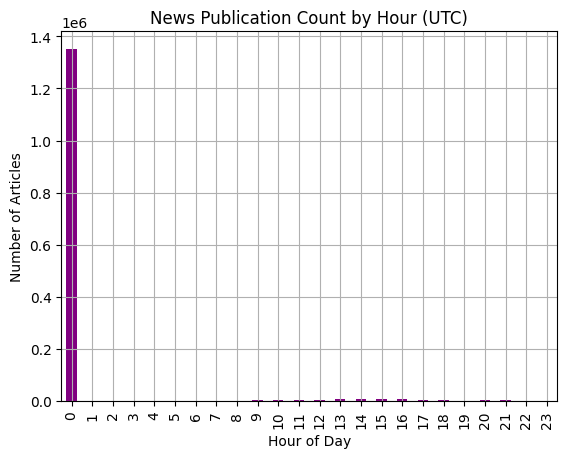

In [45]:
df['hour'] = df['date'].dt.hour

df['hour'].value_counts().sort_index().plot(kind='bar', color='purple')
plt.title("News Publication Count by Hour (UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")
plt.grid(True)
plt.show()

### 7. Most Common Words in Headlines

In [46]:
text = ' '.join(df['headline'].dropna())
text = re.sub(r'[^\w\s]', '', text.lower())
word_counts = Counter(text.split())
word_counts.most_common(10)

[('to', 402875),
 ('of', 269807),
 ('on', 245071),
 ('for', 238895),
 ('in', 220556),
 ('the', 212758),
 ('vs', 162061),
 ('stocks', 161868),
 ('est', 140578),
 ('eps', 128910)]

### Word Cloud of Keywords

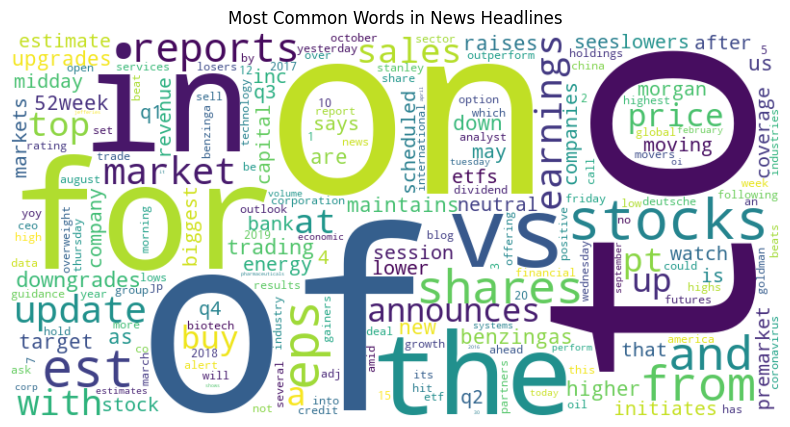

In [47]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in News Headlines")
plt.show()